# Modelo Baseline: Regresion Logistica

Notebook de entrenamiento y evaluacion del modelo baseline para predecir
zonas de alto riesgo de abandono de vivienda en Hermosillo, Sonora.

**Problema:** clasificacion binaria — `abandono_alto` (1 = alto riesgo, 0 = estable)

**Datos:** 665 AGEBs de Hermosillo, 20 features de rezago habitacional,
bienestar socioeconomico y actividad economica DENUE.

**Validacion:** Stratified K-Fold (k=5, seed=42) — mismo objeto `cv` en todo el equipo

**Tracking:** MLflow en DagsHub

## Metricas objetivo

| Metrica  | Objetivo |
|----------|----------|
| Recall   | > 0.85   |
| F1-Score | > 0.80   |
| AUC-ROC  | > 0.85   |

> El Recall es la metrica mas importante: un falso negativo significa clasificar
> una zona de alto riesgo como estable, lo que impide una intervencion oportuna.

In [1]:
import os
import sys

# El kernel arranca en notebooks/ — subir al raiz para que las rutas relativas funcionen
os.chdir('..')
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

import mlflow

from src.models.utils import (
    init_mlflow, cargar_datos, get_cv_folds,
    evaluar_modelo, log_experimento
)

## 1. Carga de datos

Se usa `cargar_datos()` de las utilidades compartidas del equipo,
que lee `train_ready.parquet` y devuelve X e y listos para modelar.

In [2]:
X, y = cargar_datos()

print(f'Shape del dataset: {X.shape}')
print(f'\nDistribucion de la variable objetivo:')
vc = y.value_counts()
print(f'  Clase 0 (estable):     {vc[0]} ({vc[0]/len(y):.1%})')
print(f'  Clase 1 (alto riesgo): {vc[1]} ({vc[1]/len(y):.1%})')
print(f'\nRatio de desbalance: {vc[0]/vc[1]:.1f}:1')

# Vista rapida de las features
print(f'\nEstadisticas descriptivas:')
X.describe().round(3)

Shape del dataset: (665, 20)

Distribucion de la variable objetivo:
  Clase 0 (estable):     553 (83.2%)
  Clase 1 (alto riesgo): 112 (16.8%)

Ratio de desbalance: 4.9:1

Estadisticas descriptivas:


,TASA_PISO_TIERRA,TASA_SIN_DRENAJE,TASA_SIN_ELEC,TASA_SIN_BIENES,TASA_1_CUARTO,TASA_LETRINA,HACINAMIENTO,SCORE_REZAGO,PRO_OCUP_C,VPH_INTER,VPH_AUTOM,VPH_PC,VPH_REFRI,GRAPROES,n_bancos,n_cafes,n_inmobiliarias,n_empenos,n_usados,n_yonques
count,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.0,665.0,665.0
mean,0.044,0.022,0.011,0.007,0.059,0.038,0.898,0.203,0.898,311.334,296.926,238.310,411.456,10.272,0.979,0.967,0.179,0.0,0.0,0.0
std,0.125,0.105,0.076,0.037,0.118,0.138,0.413,0.185,0.413,343.782,329.422,280.456,435.168,3.595,2.908,2.049,0.698,0.0,0.0,0.0
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.0
25%,0.000,0.000,0.000,0.000,0.000,0.000,0.670,0.116,0.670,36.000,35.000,28.000,54.000,9.020,0.000,0.000,0.000,0.0,0.0,0.0
50%,0.007,0.000,0.000,0.000,0.015,0.000,0.860,0.159,0.860,223.000,218.000,159.000,309.000,10.530,0.000,0.000,0.000,0.0,0.0,0.0
75%,0.014,0.000,0.000,0.000,0.038,0.000,1.110,0.228,1.110,469.000,444.000,348.000,630.000,12.550,0.000,1.000,0.000,0.0,0.0,0.0
max,0.889,1.000,0.923,0.667,0.750,1.000,3.000,2.400,3.000,2660.000,2599.000,2142.000,3887.000,16.380,27.000,21.000,7.000,0.0,0.0,0.0


## 2. Configuracion del experimento

Se inicializa la conexion con DagsHub/MLflow y se define el pipeline base.

**Por que usar un Pipeline:**
Al encadenar `StandardScaler` y `LogisticRegression` en un Pipeline,
el escalado se ajusta **solo con los datos de entrenamiento** de cada fold,
evitando data leakage hacia el conjunto de validacion.

In [3]:
# Inicializar MLflow y apuntar al experimento correcto en DagsHub
init_mlflow()
mlflow.set_experiment('regresion_logistica')

# Objeto de validacion cruzada compartido por todo el equipo
cv = get_cv_folds()  # StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_pipeline(C=1.0, penalty='l2', class_weight=None):
    """Crea un pipeline estandarizado para evitar repeticion de codigo."""
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=C,
            penalty=penalty,
            class_weight=class_weight,
            solver='liblinear',  # soporta L1 y L2, eficiente en datasets pequenos
            random_state=42,
            max_iter=1000
        ))
    ])

print('MLflow inicializado correctamente.')
print(f'Tracking URI: {mlflow.get_tracking_uri()}')

Accessing as PancakesOS

Initialized MLflow to track repo "PancakesOS/prediccion-abandono-vivienda"

Repository PancakesOS/prediccion-abandono-vivienda initialized!

MLflow inicializado correctamente.
Tracking URI: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow


## 3. Modelo Baseline

Se entrena el modelo con parametros por defecto mas `class_weight='balanced'`.

**Por que `class_weight='balanced'`:**
El dataset tiene un desbalance de ~5:1 (clase 0 vs clase 1). Sin ajuste,
el modelo aprende a predecir siempre clase 0 y obtiene ~83% de exactitud
sin detectar ningun caso de alto riesgo. El peso balanceado multiplica la
penalizacion de los errores en la clase minoritaria por `n_samples / (2 * n_clase_1)`.

In [4]:
baseline = make_pipeline(C=1.0, penalty='l2', class_weight='balanced')
metricas_baseline = evaluar_modelo(baseline, X, y)

params_baseline = {
    'C': 1.0, 'penalty': 'l2',
    'class_weight': 'balanced', 'solver': 'liblinear'
}
log_experimento('logreg_baseline', baseline, params_baseline, metricas_baseline)

print('=== Baseline (L2, C=1, balanced) ===')
print(f"  Recall:  {metricas_baseline['recall_mean']:.4f} +/- {metricas_baseline['recall_std']:.4f}")
print(f"  F1:      {metricas_baseline['f1_mean']:.4f} +/- {metricas_baseline['f1_std']:.4f}")
print(f"  AUC-ROC: {metricas_baseline['auc_mean']:.4f} +/- {metricas_baseline['auc_std']:.4f}")

2026/05/07 22:51:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/05/07 22:51:52 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda


2026/05/07 22:51:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/05/07 22:51:55 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda


2026/05/07 22:51:55 INFO mlflow.utils.environment: Detected uv project at /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda. Attempting to export requirements via 'uv export'.


2026/05/07 22:51:55 INFO mlflow.utils.uv_utils: Exported 207 dependencies via uv


2026/05/07 22:51:55 INFO mlflow.utils.environment: Successfully exported 207 requirements from uv project. Skipping package capture based inference.


2026/05/07 22:51:55 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run logreg_baseline at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/1/runs/6dc8d683a687446d86a2505097420a9a
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/1


[MLflow] 'logreg_baseline' registrado — Recall: 0.713 | F1: 0.450 | AUC: 0.773
=== Baseline (L2, C=1, balanced) ===
  Recall:  0.7134 +/- 0.0948
  F1:      0.4499 +/- 0.0560
  AUC-ROC: 0.7726 +/- 0.0754


## 4. Busqueda de hiperparametros con GridSearchCV

Se exploran sistematicamente las combinaciones de:

| Hiperparametro   | Valores explorados | Descripcion |
|------------------|--------------------|-------------|
| `C`              | 0.01, 0.1, 1, 10, 100 | Inverso de regularizacion. C bajo = mas restriccion |
| `penalty`        | l1, l2             | L1 produce modelos sparse (algunos coef = 0); L2 penaliza uniformemente |
| `class_weight`   | None, balanced     | Compensacion por desbalance de clases |

Se optimiza sobre **Recall** porque el objetivo principal es no perder
zonas de alto riesgo (minimizar falsos negativos).

In [5]:
param_grid = {
    'clf__C':            [0.01, 0.1, 1, 10, 100],
    'clf__penalty':      ['l1', 'l2'],
    'clf__class_weight': [None, 'balanced'],
}

# Pipeline base para la busqueda
pipe_grid = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(solver='liblinear', random_state=42, max_iter=1000))
])

grid_search = GridSearchCV(
    pipe_grid,
    param_grid,
    cv=cv,
    scoring='recall',   # metrica principal del proyecto
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X, y)

print(f'Mejores parametros encontrados: {grid_search.best_params_}')
print(f'Mejor Recall (CV):              {grid_search.best_score_:.4f}')

# Mostrar top 10 combinaciones ordenadas por Recall
results_df = pd.DataFrame(grid_search.cv_results_)
top10 = (
    results_df
    .sort_values('mean_test_score', ascending=False)
    .head(10)
    [['param_clf__C', 'param_clf__penalty', 'param_clf__class_weight',
      'mean_test_score', 'std_test_score']]
)
top10.columns = ['C', 'penalty', 'class_weight', 'recall_mean', 'recall_std']
top10 = top10.round(4).reset_index(drop=True)
print('\nTop 10 combinaciones por Recall:')
print(top10.to_string(index=False))

Mejores parametros encontrados: {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__penalty': 'l1'}
Mejor Recall (CV):              0.7941

Top 10 combinaciones por Recall:
     C penalty class_weight  recall_mean  recall_std
  0.10      l1     balanced       0.7941      0.0850
  0.01      l2     balanced       0.7850      0.1209
  0.10      l2     balanced       0.7490      0.1038
  1.00      l1     balanced       0.7221      0.0948
  1.00      l2     balanced       0.7134      0.0948
100.00      l1     balanced       0.7043      0.1112
 10.00      l1     balanced       0.7043      0.1112
100.00      l2     balanced       0.7043      0.1112
 10.00      l2     balanced       0.6957      0.1132
 10.00      l1         None       0.1419      0.0489


## 5. Evaluacion de los mejores modelos por tipo de regularizacion

Se selecciona el mejor modelo L1 y el mejor L2 por separado para comparar
su comportamiento. Se registra cada uno como un run independiente en MLflow
junto con todas sus metricas de validacion cruzada.

In [6]:
# Seleccionar mejor configuracion por regularizacion
# Se usa mean - std como criterio para preferir modelos mas estables
results_df['score_estable'] = results_df['mean_test_score'] - results_df['std_test_score']

best_l2_row = results_df[results_df['param_clf__penalty'] == 'l2'].nlargest(1, 'score_estable').iloc[0]
best_l1_row = results_df[results_df['param_clf__penalty'] == 'l1'].nlargest(1, 'score_estable').iloc[0]

runs_a_evaluar = {
    'logreg_best_l2': {
        'C':            float(best_l2_row['param_clf__C']),
        'penalty':      'l2',
        'class_weight': best_l2_row['param_clf__class_weight'],
    },
    'logreg_best_l1': {
        'C':            float(best_l1_row['param_clf__C']),
        'penalty':      'l1',
        'class_weight': best_l1_row['param_clf__class_weight'],
    },
}

tabla_resultados = []

for run_name, params in runs_a_evaluar.items():
    modelo = make_pipeline(**params)
    metricas = evaluar_modelo(modelo, X, y)
    log_experimento(run_name, modelo, params, metricas)
    tabla_resultados.append({'run': run_name, **params, **metricas})
    print(f"{run_name}:")
    print(f"  Recall:  {metricas['recall_mean']:.4f} +/- {metricas['recall_std']:.4f}")
    print(f"  F1:      {metricas['f1_mean']:.4f} +/- {metricas['f1_std']:.4f}")
    print(f"  AUC-ROC: {metricas['auc_mean']:.4f} +/- {metricas['auc_std']:.4f}")
    print()

# Tabla comparativa de todos los runs
tabla_df = pd.DataFrame(tabla_resultados).set_index('run')
cols_mostrar = ['C', 'penalty', 'class_weight', 'recall_mean', 'f1_mean', 'auc_mean']
print('=== Tabla comparativa de todos los experimentos ===')
print(tabla_df[cols_mostrar].round(4).to_string())

2026/05/07 22:52:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/05/07 22:52:08 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda


2026/05/07 22:52:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/05/07 22:52:18 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda


2026/05/07 22:52:18 INFO mlflow.utils.environment: Detected uv project at /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda. Attempting to export requirements via 'uv export'.


...

2026/05/07 22:52:41 INFO mlflow.utils.uv_utils: Exported 207 dependencies via uv


2026/05/07 22:52:41 INFO mlflow.utils.environment: Successfully exported 207 requirements from uv project. Skipping package capture based inference.


2026/05/07 22:52:41 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run logreg_best_l1 at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/1/runs/4addd9a97de042aba6b23becfbdc7e27
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/1


[MLflow] 'logreg_best_l1' registrado — Recall: 0.794 | F1: 0.458 | AUC: 0.771
logreg_best_l1:
  Recall:  0.7941 +/- 0.0850
  F1:      0.4579 +/- 0.0424
  AUC-ROC: 0.7707 +/- 0.0613

=== Tabla comparativa de todos los experimentos ===
                   C penalty class_weight  recall_mean  f1_mean  auc_mean
run                                                                      
logreg_best_l2  0.01      l2     balanced       0.7850   0.4239    0.7678
logreg_best_l1  0.10      l1     balanced       0.7941   0.4579    0.7707


## 6. Curvas de aprendizaje

Las curvas de aprendizaje muestran como evolucionan el error de entrenamiento
y validacion al aumentar el tamanio del conjunto de entrenamiento.

**Interpretacion:**
- Curvas convergen con error alto (Recall bajo) → **sesgo alto (underfitting)**,
  el modelo es demasiado simple o necesita mas features.
- Brecha grande entre train y val → **varianza alta (overfitting)**,
  el modelo memoriza los datos de entrenamiento.
- Curvas que convergen cerca del objetivo → buen ajuste.

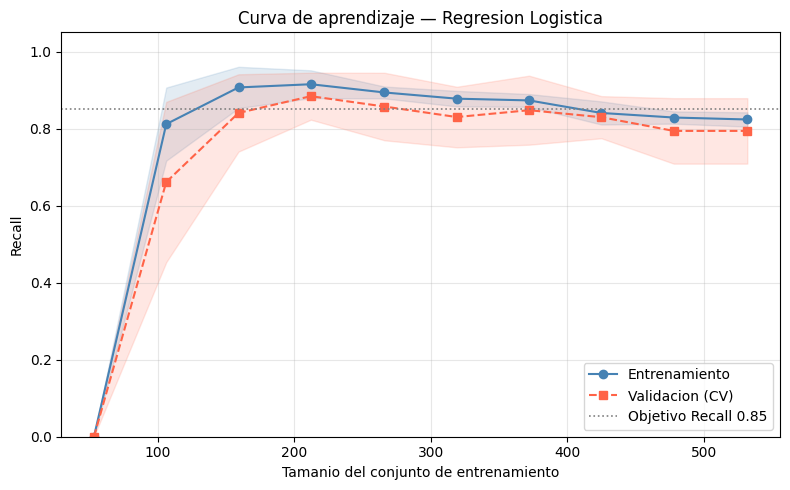

🏃 View run logreg_learning_curve_artifact at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/1/runs/f457bb6fb3e549f0935b9c1ed262c6b3
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/1


Curva guardada en: reports/figures/logreg_learning_curve.png


In [7]:
bp = grid_search.best_params_
mejor_modelo = make_pipeline(
    C=bp['clf__C'],
    penalty=bp['clf__penalty'],
    class_weight=bp['clf__class_weight']
)

train_sizes, train_scores, val_scores = learning_curve(
    mejor_modelo, X, y,
    cv=cv,
    scoring='recall',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

tr_mean = train_scores.mean(axis=1)
tr_std  = train_scores.std(axis=1)
va_mean = val_scores.mean(axis=1)
va_std  = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, tr_mean, 'o-', color='steelblue', label='Entrenamiento')
ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std,
                alpha=0.15, color='steelblue')
ax.plot(train_sizes, va_mean, 's--', color='tomato', label='Validacion (CV)')
ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std,
                alpha=0.15, color='tomato')
ax.axhline(0.85, color='gray', linestyle=':', linewidth=1.2, label='Objetivo Recall 0.85')
ax.set_xlabel('Tamanio del conjunto de entrenamiento')
ax.set_ylabel('Recall')
ax.set_title('Curva de aprendizaje — Regresion Logistica')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
fig.tight_layout()

ruta_fig = 'reports/figures/logreg_learning_curve.png'
fig.savefig(ruta_fig, dpi=150, bbox_inches='tight')
plt.show()

with mlflow.start_run(run_name='logreg_learning_curve_artifact'):
    mlflow.log_artifact(ruta_fig)

print(f'Curva guardada en: {ruta_fig}')

## 7. Matriz de confusion

Se entrena el mejor modelo en 4 folds y se evalua en el fold restante
para visualizar los tipos de error en datos no vistos.

**Tipos de error en este problema:**
- **Falso Negativo (FN):** zona de alto riesgo clasificada como estable.
  Es el error mas costoso: la zona no recibe atencion y el abandono avanza.
- **Falso Positivo (FP):** zona estable clasificada como riesgo.
  Implica recursos desperdiciados pero es menos grave que el FN.

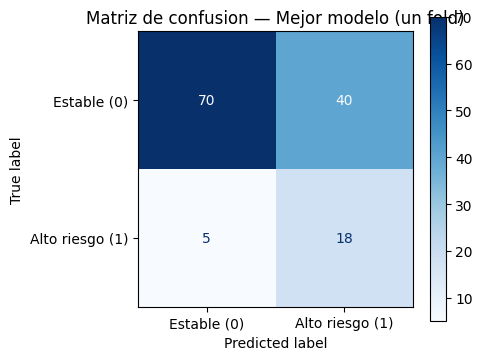

🏃 View run logreg_confusion_matrix_artifact at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/1/runs/56caac68efeb42dcaa5989326e501a07
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/1


Reporte de clasificacion (un fold):
              precision    recall  f1-score   support

     Estable       0.93      0.64      0.76       110
 Alto riesgo       0.31      0.78      0.44        23

    accuracy                           0.66       133
   macro avg       0.62      0.71      0.60       133
weighted avg       0.83      0.66      0.70       133



In [8]:
from sklearn.model_selection import StratifiedKFold

cv_viz = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = list(cv_viz.split(X, y))
train_idx, test_idx = folds[-1]

X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

modelo_viz = make_pipeline(
    C=bp['clf__C'],
    penalty=bp['clf__penalty'],
    class_weight=bp['clf__class_weight']
)
modelo_viz.fit(X_tr, y_tr)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    modelo_viz, X_te, y_te,
    display_labels=['Estable (0)', 'Alto riesgo (1)'],
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de confusion — Mejor modelo (un fold)')
fig.tight_layout()

ruta_cm = 'reports/figures/logreg_confusion_matrix.png'
fig.savefig(ruta_cm, dpi=150, bbox_inches='tight')
plt.show()

with mlflow.start_run(run_name='logreg_confusion_matrix_artifact'):
    mlflow.log_artifact(ruta_cm)

print('Reporte de clasificacion (un fold):')
print(classification_report(y_te, modelo_viz.predict(X_te),
                             target_names=['Estable', 'Alto riesgo']))

## 8. Coeficientes del modelo (interpretabilidad)

Los coeficientes de la regresion logistica (en escala estandarizada) indican:
- **Coeficiente positivo:** la feature aumenta la probabilidad de alto riesgo.
- **Coeficiente negativo:** la feature reduce la probabilidad de alto riesgo.

Al estar las features escaladas, los coeficientes son comparables entre si.

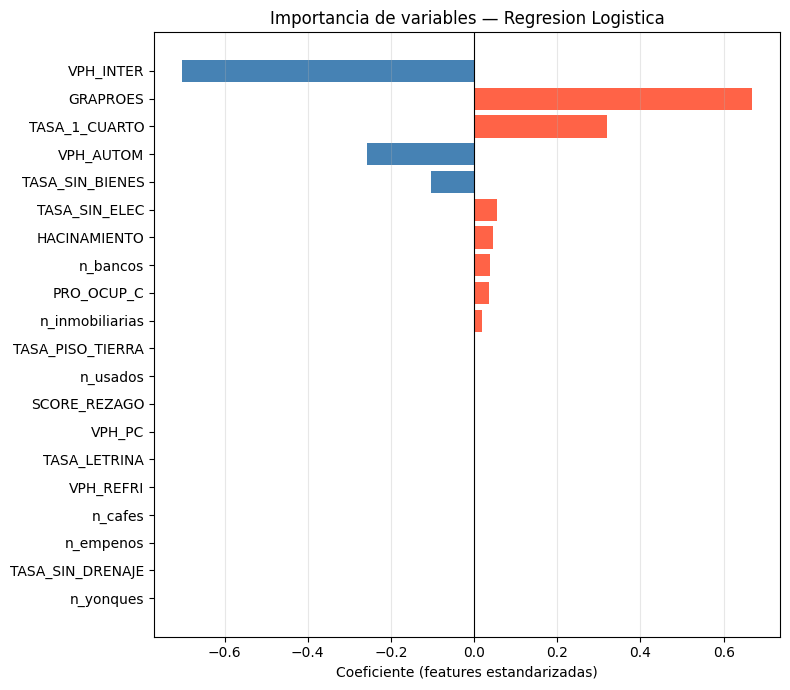

Features con mayor coeficiente positivo (predicen alto riesgo):
      feature  coeficiente
     GRAPROES     0.666993
TASA_1_CUARTO     0.319104
TASA_SIN_ELEC     0.054686
 HACINAMIENTO     0.045552
     n_bancos     0.037503

Features con mayor coeficiente negativo (predicen zona estable):
        feature  coeficiente
      VPH_INTER    -0.701319
      VPH_AUTOM    -0.258475
TASA_SIN_BIENES    -0.104435
       n_usados     0.000000
   SCORE_REZAGO     0.000000


In [9]:
coef = modelo_viz.named_steps['clf'].coef_[0]
feature_names = X.columns.tolist()

coef_df = pd.DataFrame({'feature': feature_names, 'coeficiente': coef})
coef_df = coef_df.reindex(coef_df['coeficiente'].abs().sort_values(ascending=True).index)

colores = ['tomato' if c > 0 else 'steelblue' for c in coef_df['coeficiente']]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(coef_df['feature'], coef_df['coeficiente'], color=colores)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente (features estandarizadas)')
ax.set_title('Importancia de variables — Regresion Logistica')
ax.grid(True, axis='x', alpha=0.3)
fig.tight_layout()

ruta_coef = 'reports/figures/logreg_coeficientes.png'
fig.savefig(ruta_coef, dpi=150, bbox_inches='tight')
plt.show()

print('Features con mayor coeficiente positivo (predicen alto riesgo):')
print(coef_df.sort_values('coeficiente', ascending=False).head(5).to_string(index=False))
print('\nFeatures con mayor coeficiente negativo (predicen zona estable):')
print(coef_df.sort_values('coeficiente').head(5).to_string(index=False))

## 9. Resumen de experimentos registrados

In [10]:
# Recuperar todos los runs del experimento desde MLflow para tabla final
experiment = mlflow.get_experiment_by_name('regresion_logistica')

if experiment:
    runs_mlflow = mlflow.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string=''
    )
    cols = [c for c in runs_mlflow.columns if c.startswith('metrics.') or c == 'tags.mlflow.runName']
    resumen = runs_mlflow[cols].copy()
    resumen.columns = [c.replace('metrics.', '').replace('tags.mlflow.runName', 'run') for c in resumen.columns]
    resumen = resumen[resumen['run'].notna()].sort_values('recall_mean', ascending=False)
    print('Runs registrados en MLflow (ordenados por Recall):')
    print(resumen.to_string(index=False))
else:
    print('Experimento no encontrado en MLflow.')

Runs registrados en MLflow (ordenados por Recall):
 recall_std  auc_std  f1_mean  f1_std  recall_mean  auc_mean                              run
     0.0850   0.0613   0.4579  0.0424       0.7941    0.7707                   logreg_best_l1
     0.0850   0.0613   0.4579  0.0424       0.7941    0.7707                   logreg_best_l1
     0.0850   0.0613   0.4579  0.0424       0.7941    0.7707                   logreg_best_l1
     0.1209   0.0785   0.4239  0.0560       0.7850    0.7678                   logreg_best_l2
     0.1209   0.0785   0.4239  0.0560       0.7850    0.7678                   logreg_best_l2
     0.1209   0.0785   0.4239  0.0560       0.7850    0.7678                   logreg_best_l2
     0.0948   0.0754   0.4499  0.0560       0.7134    0.7726                  logreg_baseline
     0.0948   0.0754   0.4499  0.0560       0.7134    0.7726                  logreg_baseline
     0.0948   0.0754   0.4499  0.0560       0.7134    0.7726                  logreg_baseline
        N

## 10. Conclusiones\n\nResultados obtenidos con GridSearchCV (scoring=recall, 5-fold estratificado, seed=42):\n\n| Modelo             |  C   | Penalty | class_weight | Recall | F1    | AUC-ROC |\n|--------------------|------|---------|--------------|--------|-------|---------|\n| Baseline (defecto) | 1.0  | L2      | balanced     | 0.713  | 0.450 | 0.773   |\n| Mejor L2           | 0.01 | L2      | balanced     | 0.785  | 0.424 | 0.768   |\n| **Mejor L1**       | **0.1**  | **L1** | **balanced** | **0.794** | **0.458** | **0.771** |\n\nObjetivos del proyecto: Recall > 0.85 &nbsp;|&nbsp; F1 > 0.80 &nbsp;|&nbsp; AUC-ROC > 0.85\n\n---\n\n### Hallazgos principales\n\n**1. El modelo baseline no alcanza los objetivos del proyecto.**\nEl mejor modelo (L1, C=0.1, balanced) obtiene Recall=0.794, F1=0.458 y AUC-ROC=0.771.\nNinguna de las tres metricas supera los umbrales requeridos.\n\n**2. El desbalance de clases (5:1) limita el F1.**\nEl ajuste `class_weight='balanced'` es indispensable: sin el, el modelo predice siempre\nclase 0 y obtiene Recall < 0.15. Con balanced, el Recall sube pero aumentan los falsos\npositivos, lo que penaliza la precision y, por lo tanto, el F1.\n\n**3. L1 supera ligeramente a L2 y ofrece modelos mas interpretables.**\nCon C=0.1, la regularizacion L1 anula los coeficientes de `SCORE_REZAGO` y `n_usados`,\nindicando que esas features no aportan informacion adicional una vez que las otras\nvariables de rezago ya estan presentes.\n\n**4. Features mas influyentes:**\n- Predicen **alto riesgo** (+): `GRAPROES` (escolaridad promedio), `TASA_1_CUARTO`\n- Predicen **zona estable** (-): `VPH_INTER` (internet), `VPH_AUTOM` (automovil)\n\nEl coeficiente positivo de `GRAPROES` es contra-intuitivo: sugiere que a mayor\nescolaridad promedio en el AGEB, mayor riesgo de abandono. Esto podria reflejar\nzonas de ingreso medio-alto con abandono especulativo (viviendas nuevas desocupadas),\nno abandono por carencia.\n\n**5. La curva de aprendizaje indica sesgo alto, no varianza alta.**\nEl Recall de validacion satura cerca de 0.79 con el dataset completo. Agregar mas\nobservaciones de Hermosillo no mejoraria el modelo. El problema es la capacidad\nrepresentacional del modelo lineal ante un problema con relaciones no lineales.\n\n### Proximos pasos\n\nAvanzar con **SVM (kernel RBF)**, que puede separar clases en espacios de mayor\ndimension y capturar fronteras de decision no lineales. Junto con los modelos de\nensemble (Random Forest, Gradient Boosting) del resto del equipo, se espera superar\nlos umbrales objetivo. La regresion logistica queda como linea base interpretable\nde referencia."